# Material ID : mp-961673

In [1]:
import json

# An optional utility to display a progress bar
# for long-running loops. `pip install tqdm`.
from tqdm import tqdm
#import atomate2.common.schemas.symmetry as acss
#!pip install mp-api --upgrade
import numpy as np
import matplotlib.pyplot as plt
from mp_api.client import MPRester
#from pymatgen.ext.matproj import MPRester


from jupyter_jsmol import JsmolView
from ipywidgets import Layout, widgets, interact
from IPython.display import display, Image
import os
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from jupyter_jsmol.pymatgen import quick_view
from pymatgen.electronic_structure import plotter
from pymatgen.electronic_structure import bandstructure as bs

api_key = "IDG8oerg7OP5AeRfbNjUZBb1Ad4Qke2l"
material_id = "mp-961673"

mpr = MPRester(api_key)

structure = mpr.get_structure_by_material_id(material_id)

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

# Télécharger le fichier .cif

In [2]:
from pymatgen.io.cif import CifWriter
#from pymatgen.io.xyz import XYZ

CifWriter(structure).write_file(material_id+".cif")
#XYZ(structure).write_file(material_id+".xyz")

# Déterminer la bande interdite

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Bande directe ? :  False
Energie :  0.9852000000000007 eV
Transition :  L-X


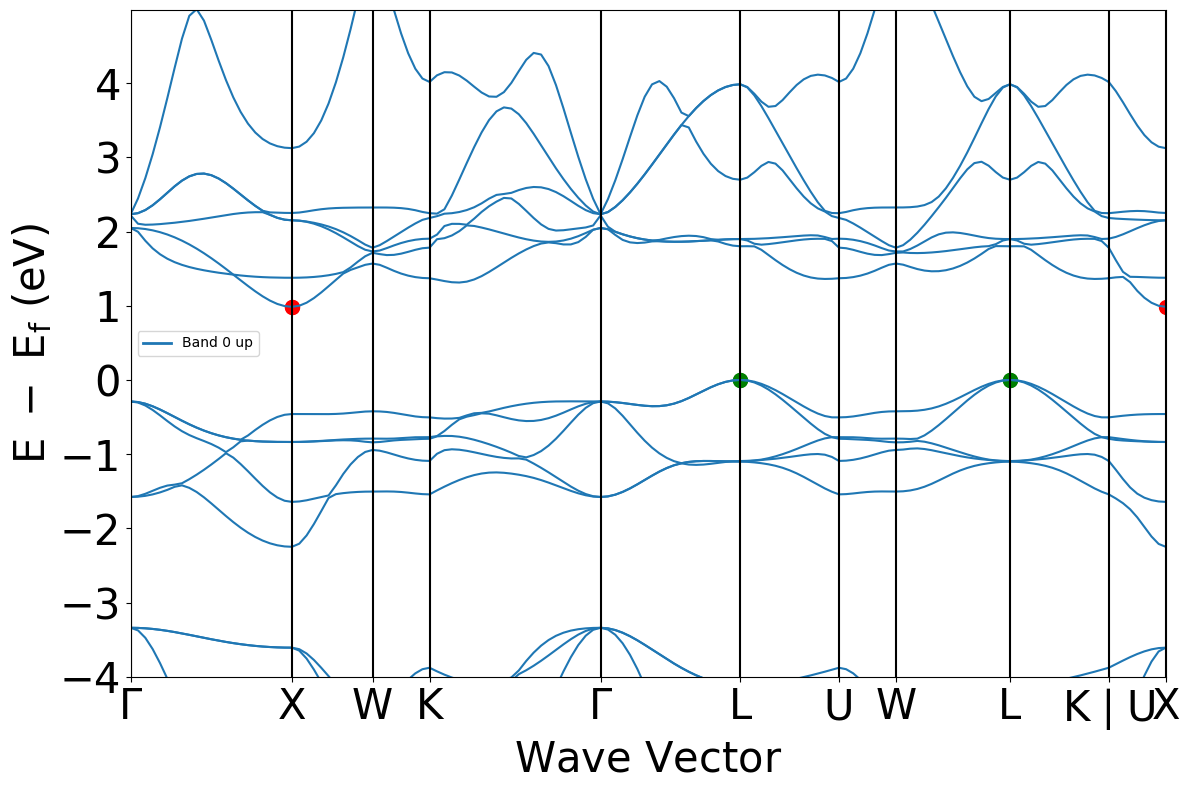

In [3]:
bands     = mpr.get_bandstructure_by_material_id(material_id) 

bplot = plotter.BSPlotter(bands)
bplot.get_plot(vbm_cbm_marker = True)

bandgap = bands.get_band_gap()
#print(bandgap)
#print("")
print("Bande directe ? : ", bandgap['direct'])
print("Energie : ", bandgap['energy'], 'eV')
print("Transition : ", bandgap['transition'])

# Trouver la direction dans laquelle la dernière (première) bande de valence (conduction) présente le plus et le moins de dispersion

In [4]:
data = bplot.bs_plot_data()['distances']
energy = bplot.bs_plot_data()['energy']

#print(data)

vbm = bands.get_vbm()
print("Index of the first Valence Band :",vbm['band_index'])

cbm = bands.get_cbm()
print("Index of the last Conduction Band :",cbm['band_index'])

Index of the first Valence Band : defaultdict(<class 'list'>, {<Spin.up: 1>: [13, 14]})
Index of the last Conduction Band : defaultdict(<class 'list'>, {<Spin.up: 1>: [15]})


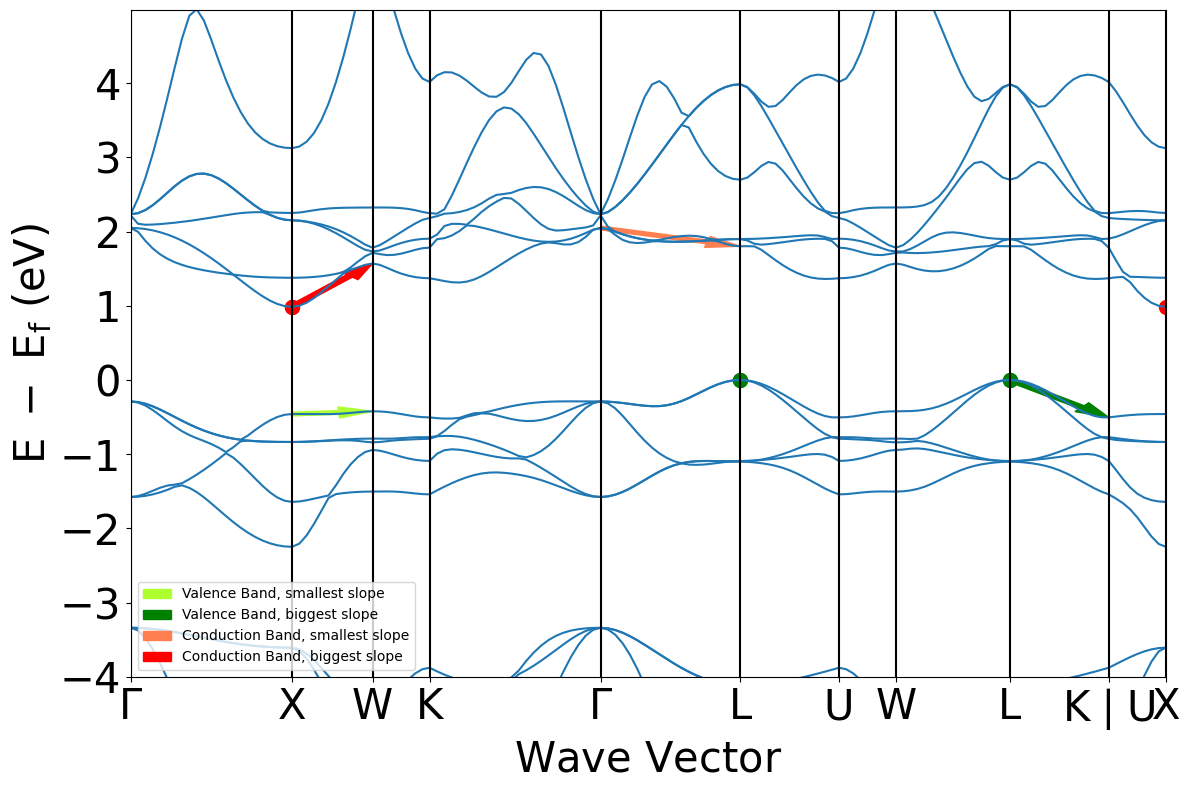

In [5]:
# pentes
slope_val  = [] #np.empty_like(data, dtype=object)
slope_cond = [] #np.empty_like(data, dtype=object)

for i in range(len(data)):
    slope_val.append(abs((energy['1'][i][14][0] - energy['1'][i][14][-1])/(data[i][-1]-data[i][0])))
    slope_cond.append(abs((energy['1'][i][15][0] - energy['1'][i][15][-1])/(data[i][-1]-data[i][0])))
    
# maximas et minimas
max_val = np.argmax(slope_val)
min_val = np.argmin(slope_val)
max_cond = np.argmax(slope_cond)
min_cond = np.argmin(slope_cond)

bplot.get_plot(vbm_cbm_marker=True)
#Pour la plus petite pente de la bande de valence -> greenyellow
plt.arrow(data[min_val][0],energy['1'][min_val][14][0],data[min_val][-1]-data[min_val][0],energy['1'][min_val][14][-1]-energy['1'][min_val][14][0],width = 0.05,length_includes_head=True,color='greenyellow', label ="Valence Band, smallest slope") 
#Pour la plus grande pente de la bande de valence -> green
plt.arrow(data[max_val][0],energy['1'][max_val][14][0],data[max_val][-1]-data[max_val][0],energy['1'][max_val][14][-1]-energy['1'][max_val][14][0],width = 0.05,length_includes_head=True,color='green', label ="Valence Band, biggest slope") 
#Pour la plus petite pente de la bande de conduction -> coral
plt.arrow(data[min_cond][0],energy['1'][min_cond][15][0],data[min_cond][-1]-data[min_cond][0],energy['1'][min_cond][15][-1]-energy['1'][min_cond][15][0],width = 0.05,length_includes_head=True,color='coral', label ="Conduction Band, smallest slope")
#Pour la plus grande pente de la bande de conduction -> red
plt.arrow(data[max_cond][0],energy['1'][max_cond][15][0],data[max_cond][-1]-data[max_cond][0],energy['1'][max_cond][15][-1]-energy['1'][max_cond][15][0],width = 0.05,length_includes_head=True,color='red', label ="Conduction Band, biggest slope")  
plt.legend(loc='lower left')
plt.show()

# Calculer la masse effective

Comme on suppose une dispersion parabolique, l'équation de la masse effective $m^*$ peut s'écrire :

\begin{equation}
    m^* = \frac{\hbar^2}{\frac{d^2E}{dk^2}}
\end{equation}
avec $\hbar$ la contante réduite de Planck.

Pour des états proches des maxima et minima de bandes, cette équation s'approxime par l'équation suivante :

\begin{equation}
    E(k)-E_0=\pm \frac{\hbar^2}{2m^*}(k_x^2+k_y^2+k_z^2) \longrightarrow m^* = \pm \frac{\hbar^2}{2\left(E(k)-E_0\right)}(k_x^2+k_y^2+k_z^2)
\end{equation}

In [6]:
h_bar = 6.582119570 * 1e-16

kpoint = vbm.get('kpoint').frac_coords

k = np.linalg.norm(kpoint)

#Récupération de l'énergie associée au VBM
E = vbm['energy']

#Calcul de la masse effective
m_e = h_bar**2*(kpoint[0]**2+kpoint[1]**2+kpoint[2]**2)/(2*E)
print('Masse effective du sommet de la dernière bande de Valence :' , m_e, ' kg')

Masse effective du sommet de la dernière bande de Valence : 2.0221313057187056e-32  kg


In [7]:
kpoint = cbm.get('kpoint').frac_coords

#Récupération de l'énergie associée au VBM
E = cbm['energy']

#Calcul de la masse effective
m_e = h_bar**2*(kpoint[0]**2+kpoint[1]**2+kpoint[2]**2)/(2*E)

print('Masse effective du sommet de la dernière bande de Valence :' , m_e, ' kg')

Masse effective du sommet de la dernière bande de Valence : 1.2008375657949625e-32  kg
